# Punto 3 (2.0) — Ruido y filtrado espacial

Tome su imagen original en escala de gris. Según lo visto en clase, genere imágenes a partir de su imagen original correspondientes a la adición de (1) ruido uniforme, (2) ruido gaussiano, (3) ruido sal y pimienta.

Para este momento deberían contar con 4 imágenes en escala de gris: la imagen original y las tres imágenes con ruido.

Construya y aplique los siguientes filtros sobre las imágenes con ruido:
- Filtro uniforme o promedio con ventana de 3x3
- Filtro uniforme o promedio con ventana de 5x5
- Filtro uniforme o promedio con ventana de 7x7
- Filtro gaussiano con ventana de 3x3 y sigma igual a 0.5
- Filtro gaussiano con ventana de 5x5 y sigma igual a 0.5
- Filtro gaussiano con ventana de 7x7 y sigma igual a 0.5
- Filtro gaussiano con ventana de 3x3 y sigma igual a 1.9
- Filtro gaussiano con ventana de 5x5 y sigma igual a 1.9
- Filtro gaussiano con ventana de 7x7 y sigma igual a 1.9

En total son 27 imágenes filtradas (9 por cada imagen con ruido). Usaremos nuevamente SSIM para identificar qué filtro funciona mejor para cada imagen, comparando cada imagen filtrada contra la imagen original (sin ruido) en escala de grises: entre mayor sea la similaridad con la imagen original, mayor será la efectividad del filtro en la eliminación del ruido.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import sys
sys.path.append("..")


## Imagen original y generación de ruido



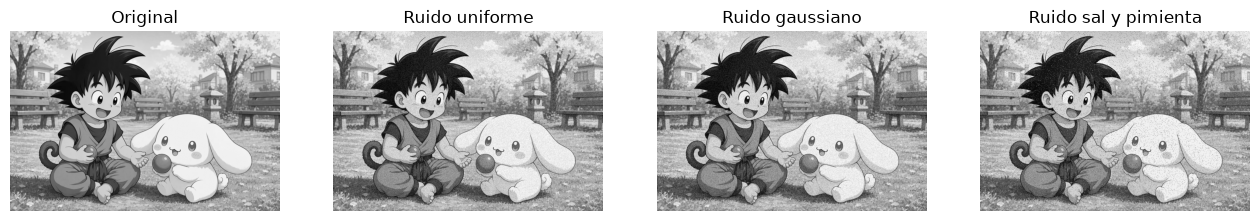

In [2]:
img = np.array(Image.open("../images/mi_imagen.png").convert("RGB"))
gray = np.array(Image.fromarray(img).convert("L"))

rng = np.random.default_rng(42)

ruido_uniforme = np.clip(gray.astype(np.float64) + rng.uniform(-40, 40, gray.shape), 0, 255).astype(np.uint8)

ruido_gaussiano = np.clip(gray.astype(np.float64) + rng.normal(0, 25, gray.shape), 0, 255).astype(np.uint8)

ruido_sal_pimienta = gray.copy()
prob = 0.05
mask = rng.random(gray.shape)
ruido_sal_pimienta[mask < prob / 2] = 0
ruido_sal_pimienta[(mask >= prob / 2) & (mask < prob)] = 255

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for ax, im, title in zip(
    axs,
    [gray, ruido_uniforme, ruido_gaussiano, ruido_sal_pimienta],
    ["Original", "Ruido uniforme", "Ruido gaussiano", "Ruido sal y pimienta"],
):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.savefig("../results/punto3_ruidos.png", bbox_inches="tight")

Image.fromarray(ruido_uniforme).save("../results/punto3_ruido_uniforme.png")
Image.fromarray(ruido_gaussiano).save("../results/punto3_ruido_gaussiano.png")
Image.fromarray(ruido_sal_pimienta).save("../results/punto3_ruido_sal_pimienta.png")


## Filtrado y tabla de SSIM

Rellene la tabla con los SSIM obtenidos para cada combinación (filtro x imagen con ruido).

In [3]:
from skimage.metrics import structural_similarity as ssim

imagenes_ruido = {
    "Ruido 1": ruido_uniforme,
    "Ruido 2": ruido_gaussiano,
    "Ruido 3": ruido_sal_pimienta,
}

filtros = {
    "F. Uniforme 3x3": lambda im: cv2.blur(im, (3, 3)),
    "F. Uniforme 5x5": lambda im: cv2.blur(im, (5, 5)),
    "F. Uniforme 7x7": lambda im: cv2.blur(im, (7, 7)),
    "Gauss 3x3 sigma=0.5": lambda im: cv2.GaussianBlur(im, (3, 3), 0.5),
    "Gauss 5x5 sigma=0.5": lambda im: cv2.GaussianBlur(im, (5, 5), 0.5),
    "Gauss 7x7 sigma=0.5": lambda im: cv2.GaussianBlur(im, (7, 7), 0.5),
    "Gauss 3x3 sigma=1.9": lambda im: cv2.GaussianBlur(im, (3, 3), 1.9),
    "Gauss 5x5 sigma=1.9": lambda im: cv2.GaussianBlur(im, (5, 5), 1.9),
    "Gauss 7x7 sigma=1.9": lambda im: cv2.GaussianBlur(im, (7, 7), 1.9),
}

tabla_ssim = {}
resultados_filtrados = {}
for fname, fn in filtros.items():
    tabla_ssim[fname] = {}
    for iname, im in imagenes_ruido.items():
        filtrada = fn(im)
        resultados_filtrados[(fname, iname)] = filtrada
        tabla_ssim[fname][iname] = ssim(filtrada, gray)

print(f"{'Filtro':<22}" + "".join(f"{n:<12}" for n in imagenes_ruido))
for fname, row in tabla_ssim.items():
    print(f"{fname:<22}" + "".join(f"{row[n] * 100:<12.2f}" for n in imagenes_ruido))


Filtro                Ruido 1     Ruido 2     Ruido 3     
F. Uniforme 3x3       72.59       70.82       63.51       
F. Uniforme 5x5       76.62       75.73       69.72       
F. Uniforme 7x7       71.74       71.31       67.81       
Gauss 3x3 sigma=0.5   51.79       49.68       49.19       
Gauss 5x5 sigma=0.5   51.79       49.68       49.19       
Gauss 7x7 sigma=0.5   51.79       49.68       49.19       
Gauss 3x3 sigma=1.9   72.86       71.07       63.82       
Gauss 5x5 sigma=1.9   78.89       77.91       71.72       
Gauss 7x7 sigma=1.9   78.53       77.89       73.26       


## Resultados — Imagen con Ruido 1

Incorpore la primera imagen con ruido y la imagen filtrada (de las 9) que mejor eliminación de ruido tuvo.

SSIM = **78.89%**

Mejor filtro: **Gauss 5x5 sigma=1.9**

Mejor filtro: Gauss 5x5 sigma=1.9
SSIM: 78.89%


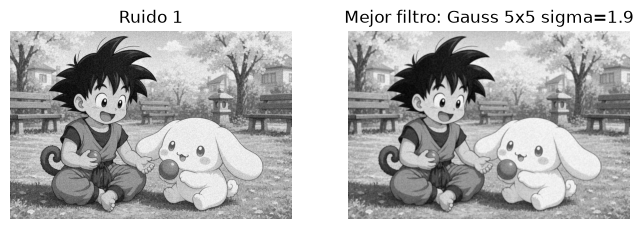

In [4]:
mejor_filtro = max(tabla_ssim.items(), key=lambda kv: kv[1]["Ruido 1"])
mejor_nombre, mejor_ssim = mejor_filtro[0], mejor_filtro[1]["Ruido 1"]
mejor_imagen = resultados_filtrados[(mejor_nombre, "Ruido 1")]

print(f"Mejor filtro: {mejor_nombre}")
print(f"SSIM: {mejor_ssim * 100:.2f}%")

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(ruido_uniforme, cmap="gray")
axs[0].set_title("Ruido 1")
axs[0].axis("off")
axs[1].imshow(mejor_imagen, cmap="gray")
axs[1].set_title(f"Mejor filtro: {mejor_nombre}")
axs[1].axis("off")
plt.savefig("../results/punto3_mejor_ruido1.png", bbox_inches="tight")


## Resultados — Imagen con Ruido 2

Incorpore la segunda imagen con ruido y la imagen filtrada (de las 9) que mejor eliminación de ruido tuvo.

SSIM = **77.91%**

Mejor filtro: **Gauss 5x5 sigma=1.9**

Mejor filtro: Gauss 5x5 sigma=1.9
SSIM: 77.91%


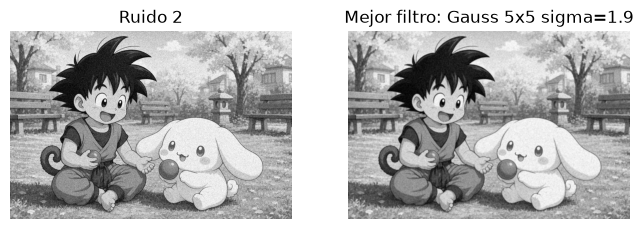

In [5]:
mejor_filtro = max(tabla_ssim.items(), key=lambda kv: kv[1]["Ruido 2"])
mejor_nombre, mejor_ssim = mejor_filtro[0], mejor_filtro[1]["Ruido 2"]
mejor_imagen = resultados_filtrados[(mejor_nombre, "Ruido 2")]

print(f"Mejor filtro: {mejor_nombre}")
print(f"SSIM: {mejor_ssim * 100:.2f}%")

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(ruido_gaussiano, cmap="gray")
axs[0].set_title("Ruido 2")
axs[0].axis("off")
axs[1].imshow(mejor_imagen, cmap="gray")
axs[1].set_title(f"Mejor filtro: {mejor_nombre}")
axs[1].axis("off")
plt.savefig("../results/punto3_mejor_ruido2.png", bbox_inches="tight")


## Resultados — Imagen con Ruido 3

Incorpore la tercera imagen con ruido y la imagen filtrada (de las 9) que mejor eliminación de ruido tuvo.

SSIM = **73.26%**

Mejor filtro: **Gauss 7x7 sigma=1.9**

Mejor filtro: Gauss 7x7 sigma=1.9
SSIM: 73.26%


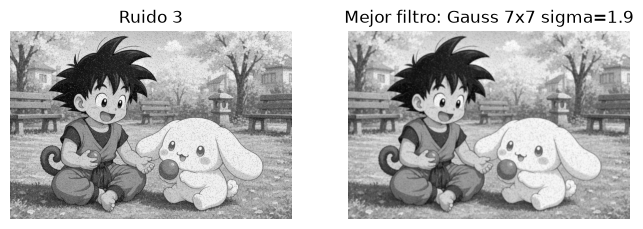

In [6]:
mejor_filtro = max(tabla_ssim.items(), key=lambda kv: kv[1]["Ruido 3"])
mejor_nombre, mejor_ssim = mejor_filtro[0], mejor_filtro[1]["Ruido 3"]
mejor_imagen = resultados_filtrados[(mejor_nombre, "Ruido 3")]

print(f"Mejor filtro: {mejor_nombre}")
print(f"SSIM: {mejor_ssim * 100:.2f}%")

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(ruido_sal_pimienta, cmap="gray")
axs[0].set_title("Ruido 3")
axs[0].axis("off")
axs[1].imshow(mejor_imagen, cmap="gray")
axs[1].set_title(f"Mejor filtro: {mejor_nombre}")
axs[1].axis("off")
plt.savefig("../results/punto3_mejor_ruido3.png", bbox_inches="tight")
